In [1]:
# Importing standard libraries
import os
import math
import numpy as np
import pandas as pd
import cv2
# Importing libraries from TensorFlow and Keras for deep learning
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalMaxPooling2D,
)
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
# Importing libraries for model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings
warnings.simplefilter("always")

# Importing libraries for handling DICOM files and displaying progress
import pydicom as dcm
from glob import glob
from tqdm import notebook

import matplotlib.pyplot as plt


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adagrad,Adam


In [4]:
labels_dir = "labels/"
output_dir = "output/"
data_dir = "data/"
train_images_dir = "stage_2_train_images/"
test_images_dir = "stage_2_test_images/"

TRAIN_IMAGE_LABELS_FILE = os.path.join(labels_dir, "stage_2_train_labels.csv")
CLASS_INFO_FILE = os.path.join(labels_dir, "stage_2_detailed_class_info.csv")
TEST_IMAGE_LABELS_FILE = os.path.join(labels_dir, "stage_2_test_labels.csv")

In [5]:
# Read the data from the saved numpy files to avoid running the previous cells
PATIENT_IDS = np.load(data_dir + "patientIds.npy")
TARGETS = np.load(data_dir + "targets.npy")
TRAIN_IMAGES = np.load(data_dir + "trainImages.npy")

X = TRAIN_IMAGES

y = to_categorical(TARGETS)
NUM_CLASSES = 2

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [6]:
HEIGHT = 128
WIDTH = 128
NUM_CHANNELS = 3
NUM_CLASSES = 2

model3333333333333 = Sequential()
model3.add(Input(shape=(HEIGHT, WIDTH, NUM_CHANNELS)))

# Start with fewer filters and lower dropout rate
model3.add(Conv2D(filters=8, kernel_size=(3, 3), activation="relu"))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(Dropout(0.05))

model3.add(Conv2D(filters=16, kernel_size=(3, 3), activation="relu"))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(Dropout(0.05))

model3.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(Dropout(0.10))

model3.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(Dropout(0.10))

model3.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(Dropout(0.15))

model3.add(GlobalMaxPooling2D())
model3.add(Dense(256, activation="relu"))
model3.add(Dropout(0.5))
model3.add(Dense(NUM_CLASSES, activation="softmax"))

model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model3.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,922 (515.32 KB)

 Trainable params: 131,922 (515.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
mcp_save = ModelCheckpoint(
    output_dir + "model3.keras", save_best_only=True, monitor="val_loss", mode="min"
)

history_model3 = model3.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[mcp_save],
)

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.6850 - loss: 1.5169 - val_accuracy: 0.7729 - val_loss: 0.4800
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.7715 - loss: 0.4829 - val_accuracy: 0.7855 - val_loss: 0.4564
Epoch 3/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.7836 - loss: 0.4598 - val_accuracy: 0.7886 - val_loss: 0.4561
Epoch 4/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.7844 - loss: 0.4578 - val_accuracy: 0.7908 - val_loss: 0.4511
Epoch 5/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.7890 - loss: 0.4477 - val_accuracy: 0.7989 - val_loss: 0.4389
Epoch 6/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.7878 - loss: 0.4521 - val_accuracy: 0.8075 - val_loss: 0.4316
Epoch 7/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.7989 - loss: 0.4340 - val_accuracy: 0.7966 - val_loss: 0.4410
Epoch 8/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.7952 - loss: 0.4400 - 

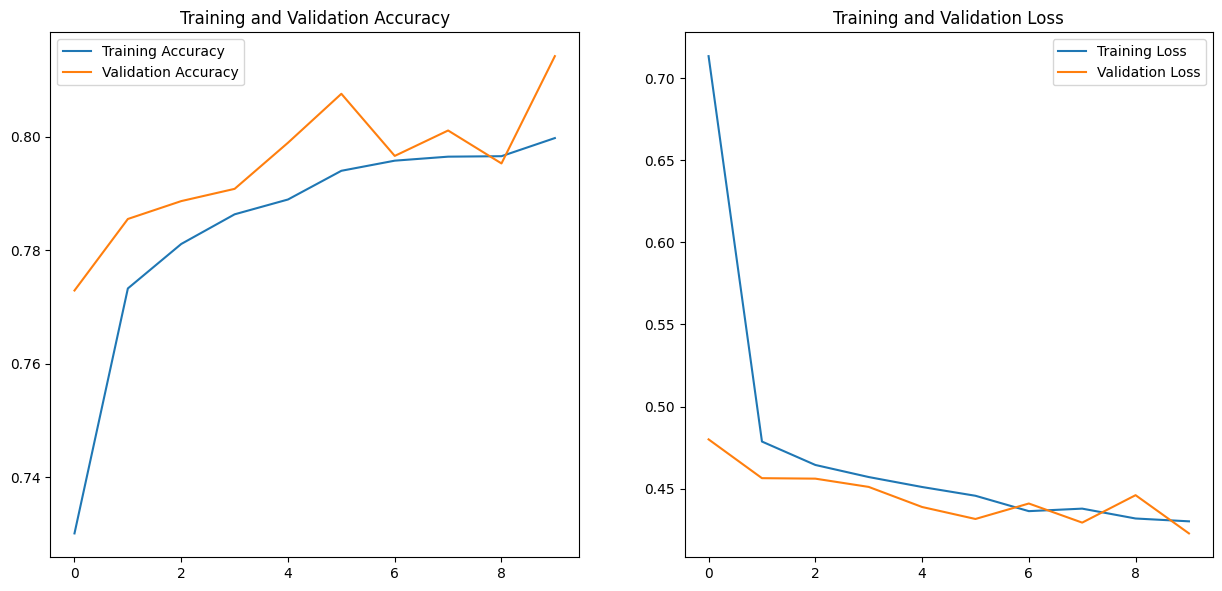

In [9]:
accuracy = history_model3.history["accuracy"]
val_accuracy = history_model3.history["val_accuracy"]
loss = history_model3.history["loss"]
val_loss = history_model3.history["val_loss"]

# Generate x values based on the length of accuracy
epochs = len(accuracy)
N = range(epochs)

plt.figure(figsize=(15, 15))

plt.subplot(2, 2, 1)
plt.plot(N, accuracy, label="Training Accuracy")
plt.plot(N, val_accuracy, label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(2, 2, 2)
plt.plot(N, loss, label="Training Loss")
plt.plot(N, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, Dense
from tensorflow.keras import backend as K

def print_tensor_shape(tensor):
    shape = K.int_shape(tensor)
    print(f"Shape after {tensor.name}: {shape}")
    return tensor

inputs = Input(shape=(HEIGHT, WIDTH, NUM_CHANNELS))

x = Conv2D(filters=16, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
x = print_tensor_shape(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.05)(x)

x = Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = print_tensor_shape(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.10)(x)

x = Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = print_tensor_shape(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.15)(x)

x = Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = print_tensor_shape(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

x = GlobalMaxPooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model31 = Model(inputs=inputs, outputs=outputs)
model31.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model31.summary()


Shape after keras_tensor_661: (None, 128, 128, 16)
Shape after keras_tensor_664: (None, 64, 64, 32)
Shape after keras_tensor_667: (None, 32, 32, 64)
Shape after keras_tensor_670: (None, 16, 16, 128)


Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,514 (642.63 KB)

 Trainable params: 164,514 (642.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
mcp_save = ModelCheckpoint(
    output_dir + "model31.keras", save_best_only=True, monitor="val_loss", mode="min"
)

history_model31 = model31.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=40,
    callbacks=[mcp_save],
)

Epoch 1/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 73s 121ms/step - accuracy: 0.7026 - loss: 0.5581 - val_accuracy: 0.6565 - val_loss: 0.6250
Epoch 2/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 75s 124ms/step - accuracy: 0.7092 - loss: 0.5535 - val_accuracy: 0.6896 - val_loss: 0.5774
Epoch 3/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 80s 133ms/step - accuracy: 0.7226 - loss: 0.5421 - val_accuracy: 0.7053 - val_loss: 0.5623
Epoch 4/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 78s 129ms/step - accuracy: 0.7194 - loss: 0.5368 - val_accuracy: 0.7201 - val_loss: 0.5354
Epoch 5/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 80s 133ms/step - accuracy: 0.7200 - loss: 0.5358 - val_accuracy: 0.7169 - val_loss: 0.5534
Epoch 6/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 73s 121ms/step - accuracy: 0.7337 - loss: 0.5210 - val_accuracy: 0.7230 - val_loss: 0.5464
Epoch 7/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 72s 120ms/step - accuracy: 0.7334 - loss: 0.5246 - val_accuracy: 0.7328 - val_loss: 0.5225
Epoch 8/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 75s 123ms/step - accuracy: 0.7307 - loss: 0

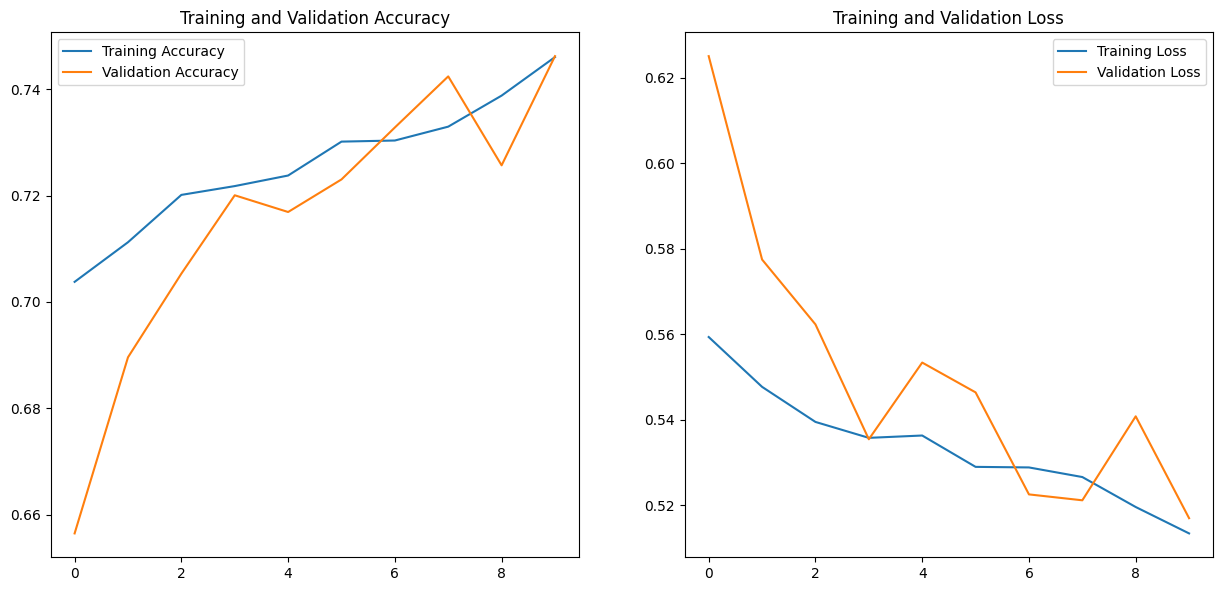

In [20]:
accuracy = history_model31.history["accuracy"]
val_accuracy = history_model31.history["val_accuracy"]
loss = history_model31.history["loss"]
val_loss = history_model31.history["val_loss"]

# Generate x values based on the length of accuracy
epochs = len(accuracy)
N = range(epochs)

plt.figure(figsize=(15, 15))

plt.subplot(2, 2, 1)
plt.plot(N, accuracy, label="Training Accuracy")
plt.plot(N, val_accuracy, label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(2, 2, 2)
plt.plot(N, loss, label="Training Loss")
plt.plot(N, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()

In [21]:
model32 = Sequential()
model32.add(Input(shape=(HEIGHT, WIDTH, NUM_CHANNELS)))

# Start with fewer filters and lower dropout rate
model32.add(Conv2D(filters=8, kernel_size=(3, 3), activation="relu"))
model32.add(MaxPooling2D(pool_size=(2, 2)))
model32.add(Dropout(0.20))

model32.add(Conv2D(filters=16, kernel_size=(3, 3), activation="relu"))
model32.add(MaxPooling2D(pool_size=(2, 2)))
model32.add(Dropout(0.25))

model32.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model32.add(MaxPooling2D(pool_size=(2, 2)))
model32.add(Dropout(0.30))

model32.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model32.add(MaxPooling2D(pool_size=(2, 2)))
model32.add(Dropout(0.35))

model32.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
model32.add(MaxPooling2D(pool_size=(2, 2)))
model32.add(Dropout(0.40))

model32.add(GlobalMaxPooling2D())
model32.add(Dense(256, activation="relu"))
model32.add(Dropout(0.5))
model32.add(Dense(NUM_CLASSES, activation="softmax"))

model32.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model32.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 126, 126, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_5          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,922 (515.32 KB)

 Trainable params: 131,922 (515.32 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
mcp_save = ModelCheckpoint(
    output_dir + "model32.keras", save_best_only=True, monitor="val_loss", mode="min"
)

history_model32 = model32.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=40,
    callbacks=[mcp_save],
)

Epoch 1/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.6168 - loss: 5.5473 - val_accuracy: 0.6899 - val_loss: 0.6856
Epoch 2/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.6873 - loss: 0.6157 - val_accuracy: 0.6569 - val_loss: 0.6640
Epoch 3/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.7357 - loss: 0.5325 - val_accuracy: 0.7444 - val_loss: 0.5883
Epoch 4/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.7503 - loss: 0.5176 - val_accuracy: 0.7326 - val_loss: 0.6063
Epoch 5/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.7589 - loss: 0.5048 - val_accuracy: 0.7732 - val_loss: 0.5492
Epoch 6/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.7657 - loss: 0.4968 - val_accuracy: 0.7517 - val_loss: 0.5586
Epoch 7/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.7644 - loss: 0.5017 - val_accuracy: 0.7449 - val_loss: 0.5567
Epoch 8/10
604/604 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7739 - loss: 0.4792 - 

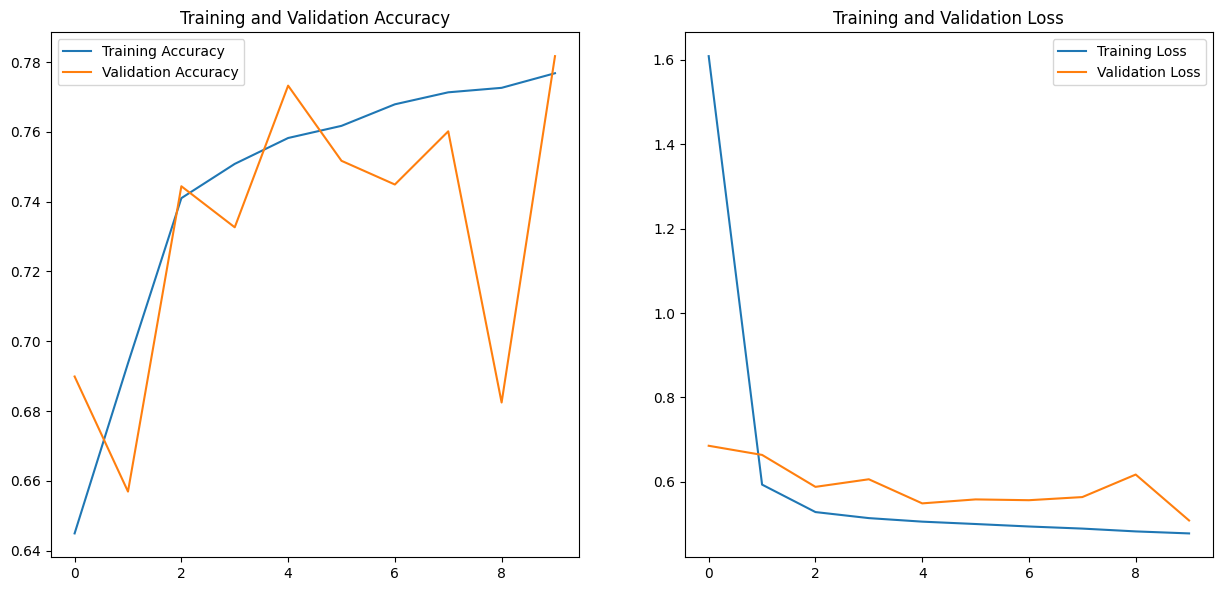

In [23]:
accuracy = history_model32.history["accuracy"]
val_accuracy = history_model32.history["val_accuracy"]
loss = history_model32.history["loss"]
val_loss = history_model32.history["val_loss"]

# Generate x values based on the length of accuracy
epochs = len(accuracy)
N = range(epochs)

plt.figure(figsize=(15, 15))

plt.subplot(2, 2, 1)
plt.plot(N, accuracy, label="Training Accuracy")
plt.plot(N, val_accuracy, label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(2, 2, 2)
plt.plot(N, loss, label="Training Loss")
plt.plot(N, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, Dense, Input, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2

HEIGHT = 128
WIDTH = 128
NUM_CHANNELS = 3
NUM_CLASSES = 2

model33 = Sequential()
model33.add(Input(shape=(HEIGHT, WIDTH, NUM_CHANNELS)))

model33.add(Conv2D(filters=8, kernel_size=(3, 3), kernel_regularizer=l2(0.001)))
model33.add(LeakyReLU(alpha=0.1))
model33.add(BatchNormalization())
model33.add(MaxPooling2D(pool_size=(2, 2)))
model33.add(Dropout(0.1))

model33.add(Conv2D(filters=16, kernel_size=(3, 3), kernel_regularizer=l2(0.001)))
model33.add(LeakyReLU(alpha=0.1))
model33.add(BatchNormalization())
model33.add(MaxPooling2D(pool_size=(2, 2)))
model33.add(Dropout(0.1))

model33.add(Conv2D(filters=32, kernel_size=(3, 3), kernel_regularizer=l2(0.001)))
model33.add(LeakyReLU(alpha=0.1))
model33.add(BatchNormalization())
model33.add(MaxPooling2D(pool_size=(2, 2)))
model33.add(Dropout(0.15))

model33.add(Conv2D(filters=64, kernel_size=(3, 3), kernel_regularizer=l2(0.001)))
model33.add(LeakyReLU(alpha=0.1))
model33.add(BatchNormalization())
model33.add(MaxPooling2D(pool_size=(2, 2)))
model33.add(Dropout(0.15))

model33.add(Conv2D(filters=128, kernel_size=(3, 3), kernel_regularizer=l2(0.001)))
model33.add(LeakyReLU(alpha=0.1))
model33.add(BatchNormalization())
model33.add(MaxPooling2D(pool_size=(2, 2)))
model33.add(Dropout(0.2))

model33.add(GlobalMaxPooling2D())
model33.add(Dense(256, activation="relu"))
model33.add(Dropout(0.5))
model33.add(Dense(NUM_CLASSES, activation="softmax"))

model33.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model33.summary()


C:\Users\PraneelSreekesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
C:\Users\PraneelSreekesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
C:\Users\PraneelSreekesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
C:\Users\PraneelSreekesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
C:\Users\PraneelSreekesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is depr

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 126, 126, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 126, 126, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 126, 126, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 61, 61, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 128)      │           51

 Total params: 132,914 (519.20 KB)

 Trainable params: 132,418 (517.26 KB)

 Non-trainable params: 496 (1.94 KB)

In [26]:
mcp_save = ModelCheckpoint(
    output_dir + "model33.keras", save_best_only=True, monitor="val_loss", mode="min"
)

history_model33 = model33.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=40,
    callbacks=[mcp_save],
)

Epoch 1/10
 89/604 ━━━━━━━━━━━━━━━━━━━━ 1:00 118ms/step - accuracy: 0.6684 - loss: 1.4813